# Notebook 4: Neural Probabilistic Classifier

**Key idea:** Replace the linear function with a neural network. Same probabilistic model.

$$p(y=1 \mid \mathbf{x}) = \sigma(f_\theta(\mathbf{x})) \qquad \text{where } f_\theta = \text{neural network}$$

We compare with logistic regression on: decision boundary, predictions, and **calibration**.

## 0. Setup

In [1]:
!pip install pyro-ppl scikit-learn -q

You should consider upgrading via the '/Users/zp25hk/Library/CloudStorage/GoogleDrive-andresrmasegosa@gmail.com/My Drive/teaching/2026-Spring/2026-PhD-PML-Claude/.venv/bin/python3 -m pip install --upgrade pip' command.


In [2]:
import torch
import torch.nn as nn
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import Adam
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

pyro.set_rng_seed(42)
torch.manual_seed(42)
np.random.seed(42)
pyro.clear_param_store()

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 12
FIGURES_DIR = 'figures/'
import os
os.makedirs(FIGURES_DIR, exist_ok=True)


## 1. Same data as Notebook 3

In [3]:

X_train, y_train = make_moons(n_samples=500, noise=0.25, random_state=42)
X_val, y_val = make_moons(n_samples=5000, noise=0.25, random_state=42)
X_test, y_test = make_moons(n_samples=5000, noise=0.25, random_state=42)



x_train = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
x_val = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)
x_test = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

print(f'Train: {len(x_train)},  Validation: {len(x_val)},  Test: {len(x_test)}')

Train: 500,  Validation: 5000,  Test: 5000


## 2. Neural network model

Compare with Notebook 3 — the **only change** is using a neural net for the logits.

In [4]:
class ClassifierNN(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

net = ClassifierNN()
pyro.nn.module.to_pyro_module_(net)

def nn_classifier_model(x, y=None):
    logits = net(x)                    # <-- only change: neural net instead of w^T x + b
    with pyro.plate('data', len(x)):
        pyro.sample('obs', dist.Bernoulli(logits=logits), obs=y)

def empty_guide(x, y=None):
    pass

print('Same Bernoulli model, but with a neural network for logits.')

Same Bernoulli model, but with a neural network for logits.


## 3. Training

Step  500 | Loss: 43.04
Step 1000 | Loss: 40.09
Step 1500 | Loss: 37.80
Step 2000 | Loss: 28.62
Step 2500 | Loss: 24.96
Step 3000 | Loss: 22.97
Step 3500 | Loss: 22.17
Step 4000 | Loss: 21.06


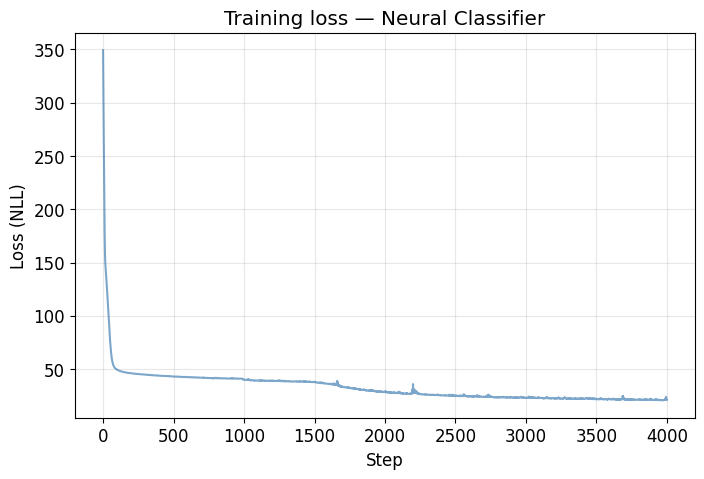

In [5]:
pyro.clear_param_store()
svi = SVI(nn_classifier_model, empty_guide, Adam({'lr': 0.01}), loss=Trace_ELBO())

losses = []
for step in range(4000):
    loss = svi.step(x_train, y_train_t)
    losses.append(loss)
    if (step + 1) % 500 == 0:
        print(f'Step {step+1:4d} | Loss: {loss:.2f}')

plt.plot(losses, color='steelblue', alpha=0.7)
plt.xlabel('Step'); plt.ylabel('Loss (NLL)')
plt.title('Training loss — Neural Classifier'); plt.grid(True, alpha=0.3)
plt.show()

## 4. Decision boundary comparison

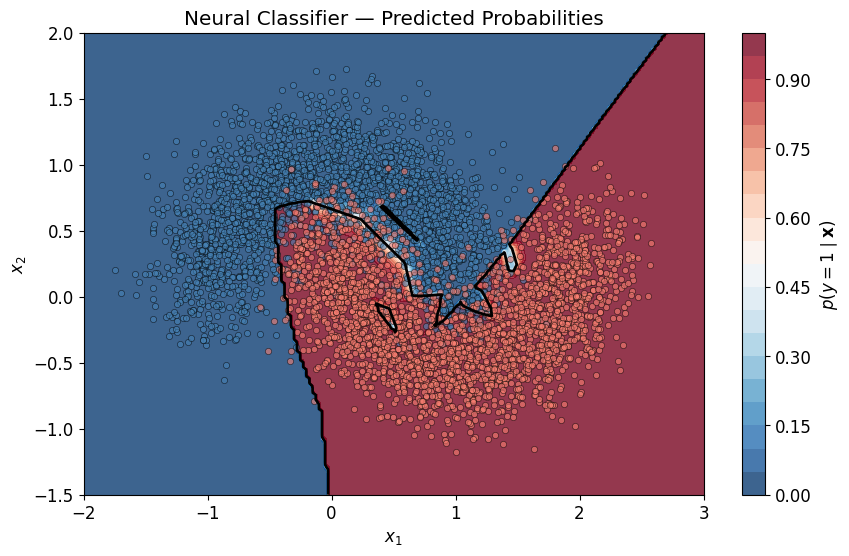

Neural net test accuracy: 0.926


In [6]:
# Grid predictions
xx, yy = np.meshgrid(np.linspace(-2, 3, 200), np.linspace(-1.5, 2, 200))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
with torch.no_grad():
    grid_probs = torch.sigmoid(net(grid)).numpy().reshape(xx.shape)

plt.figure(figsize=(10, 6))
contour = plt.contourf(xx, yy, grid_probs, levels=20, cmap='RdBu_r', alpha=0.8)
plt.colorbar(contour, label='$p(y=1 \mid \mathbf{x})$')
plt.contour(xx, yy, grid_probs, levels=[0.5], colors='black', linewidths=2)
plt.scatter(X_test[y_test==0, 0], X_test[y_test==0, 1], s=20, alpha=0.6, c='steelblue', edgecolors='k', linewidths=0.5)
plt.scatter(X_test[y_test==1, 0], X_test[y_test==1, 1], s=20, alpha=0.6, c='salmon', edgecolors='k', linewidths=0.5)
plt.xlabel('$x_1$'); plt.ylabel('$x_2$')
plt.title('Neural Classifier — Predicted Probabilities')
plt.savefig(f'{FIGURES_DIR}neural_decision_boundary.png', dpi=150, bbox_inches='tight')
plt.show()

# Accuracy
with torch.no_grad():
    probs_test_nn = torch.sigmoid(net(x_test))
preds_nn = (probs_test_nn > 0.5).float()
acc_nn = (preds_nn == y_test_t).float().mean().item()
print(f'Neural net test accuracy: {acc_nn:.3f}')

## 5. Calibration comparison

The key question: the neural net is more accurate, but is it also **better calibrated**?

In [7]:
# Reuse reliability_diagram function
def reliability_diagram(probs, labels, n_bins=10, ax=None, title='Reliability Diagram', color='steelblue'):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_accs, bin_confs, bin_counts = [], [], []
    for i in range(n_bins):
        mask = (probs >= bin_edges[i]) & (probs < bin_edges[i+1])
        if mask.sum() > 0:
            bin_accs.append(labels[mask].mean())
            bin_confs.append(probs[mask].mean())
            bin_counts.append(mask.sum())
        else:
            bin_accs.append(np.nan); bin_confs.append(np.nan); bin_counts.append(0)
    bin_accs, bin_confs, counts = np.array(bin_accs), np.array(bin_confs), np.array(bin_counts)
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect')
    ax.bar(bin_centers, bin_accs, width=1/n_bins*0.8, alpha=0.7, color=color, edgecolor='k', linewidth=0.5)
    ax.set_xlabel('Predicted probability'); ax.set_ylabel('Observed frequency')
    ax.set_title(title); ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.legend(); ax.set_aspect('equal')
    valid = ~np.isnan(bin_accs)
    if valid.any():
        ece = np.average(np.abs(bin_accs[valid] - bin_confs[valid]), weights=counts[valid])
        ax.text(0.05, 0.9, f'ECE = {ece:.3f}', transform=ax.transAxes, fontsize=12)
    return ax

# We need the logistic regression predictions from Notebook 3.
# Let's quickly retrain it here for the comparison.
pyro.clear_param_store()
def logistic_model(x, y=None):
    w = pyro.param('w_lr', torch.zeros(2))
    b = pyro.param('b_lr', torch.tensor(0.0))
    logits = x @ w + b
    with pyro.plate('data', len(x)):
        pyro.sample('obs', dist.Bernoulli(logits=logits), obs=y)

svi_lr = SVI(logistic_model, empty_guide, Adam({'lr': 0.05}), loss=Trace_ELBO())
for step in range(1000):
    svi_lr.step(x_train, y_train_t)

w_lr = pyro.param('w_lr').detach()
b_lr = pyro.param('b_lr').detach().item()
probs_test_lr = torch.sigmoid(x_test @ w_lr + b_lr).numpy()
probs_test_nn_np = probs_test_nn.numpy()

print('Both models trained. Now comparing calibration...')

Both models trained. Now comparing calibration...


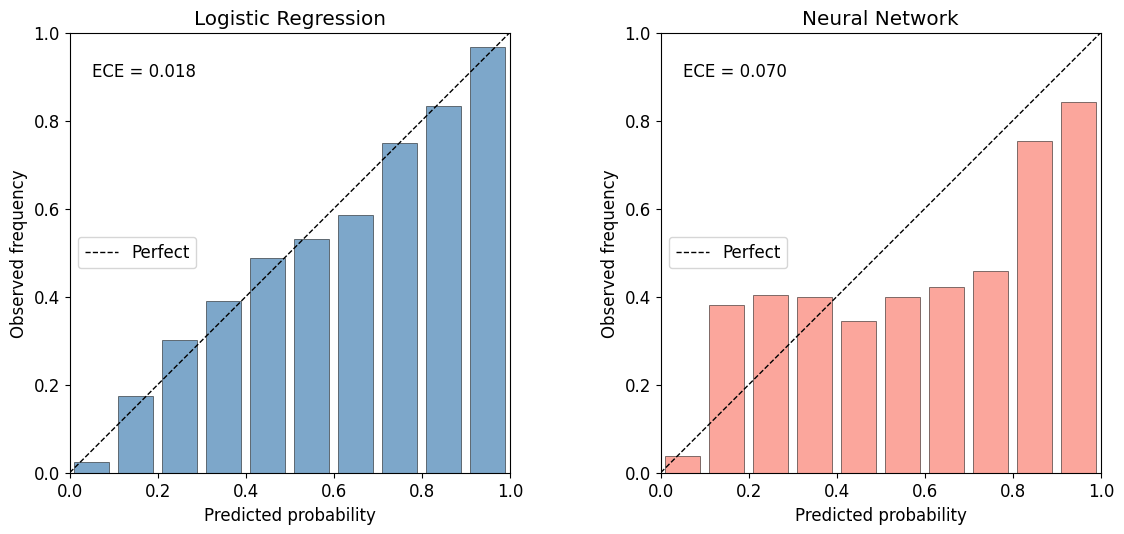

Logistic regression accuracy: 0.860
Neural network accuracy:      0.926

Compare the ECE values and bar positions.
More accuracy does not always mean better calibration!


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

reliability_diagram(probs_test_lr, y_test, n_bins=10, ax=axes[0],
                    title='Logistic Regression', color='steelblue')
reliability_diagram(probs_test_nn_np, y_test, n_bins=10, ax=axes[1],
                    title='Neural Network', color='salmon')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}calibration_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

acc_lr = ((probs_test_lr > 0.5) == y_test).mean()
print(f'Logistic regression accuracy: {acc_lr:.3f}')
print(f'Neural network accuracy:      {acc_nn:.3f}')
print()
print('Compare the ECE values and bar positions.')
print('More accuracy does not always mean better calibration!')

## 6. Fixing calibration: Temperature Scaling

The neural network is overconfident. Can we fix it **without retraining**?

**Temperature scaling** is the simplest post-hoc calibration method:

$$p_{\text{calibrated}} = \sigma\!\left(\frac{z}{T}\right)$$

where $z$ are the original logits and $T > 1$ "softens" the predictions.

We learn a **single parameter** $T$ by minimizing the NLL on the **validation set** (never the test set — that would leak information and give us an overly optimistic view of calibration quality).

In [9]:
# Temperature scaling: learn T by minimizing NLL on the VALIDATION set
# This is the correct approach — T is a hyperparameter, so it must NOT be
# fitted on the test set (which is reserved for final evaluation only).

# Get logits from the neural network on the validation set
with torch.no_grad():
    logits_val = net(x_val)

# Learn T via gradient descent on the validation NLL
log_T = torch.nn.Parameter(torch.zeros(1))  # log(T) so T is always positive
optimizer = torch.optim.LBFGS([log_T], lr=0.01, max_iter=50)

def closure():
    optimizer.zero_grad()
    T = torch.exp(log_T)
    scaled_logits = logits_val / T
    loss = torch.nn.functional.binary_cross_entropy_with_logits(scaled_logits, y_val_t)
    loss.backward()
    return loss

optimizer.step(closure)

T_learned = torch.exp(log_T).item()
print(f'Learned temperature: T = {T_learned:.3f}')
print(f'T > 1 means the model was overconfident (predictions are softened).')
print(f'(Fitted on {len(x_val)} validation samples, evaluated on {len(x_test)} test samples.)')

# Apply temperature scaling to the TEST set (unseen during T fitting)
with torch.no_grad():
    logits_test = net(x_test)
probs_test_nn_calibrated = torch.sigmoid(logits_test / T_learned).detach().numpy()

Learned temperature: T = 1.605
T > 1 means the model was overconfident (predictions are softened).
(Fitted on 5000 validation samples, evaluated on 5000 test samples.)


/Users/zp25hk/Library/CloudStorage/GoogleDrive-andresrmasegosa@gmail.com/My Drive/teaching/2026-Spring/2026-PhD-PML-Claude/.venv/lib/python3.9/site-packages/torch/optim/lbfgs.py:457: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  loss = float(closure())


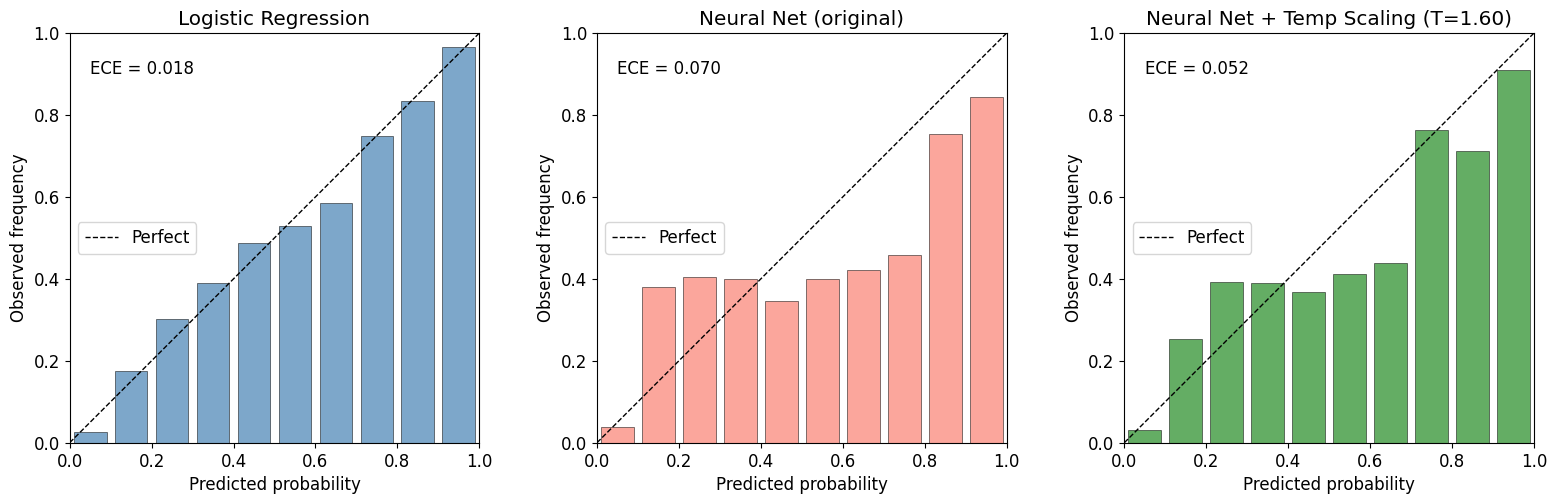

Temperature scaling: ONE parameter dramatically improves calibration.
The accuracy stays the same — only the probabilities become more reliable.


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

reliability_diagram(probs_test_lr, y_test, n_bins=10, ax=axes[0],
                    title='Logistic Regression', color='steelblue')
reliability_diagram(probs_test_nn_np, y_test, n_bins=10, ax=axes[1],
                    title='Neural Net (original)', color='salmon')
reliability_diagram(probs_test_nn_calibrated, y_test, n_bins=10, ax=axes[2],
                    title=f'Neural Net + Temp Scaling (T={T_learned:.2f})', color='forestgreen')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}temperature_scaling.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Temperature scaling: ONE parameter dramatically improves calibration.')
print(f'The accuracy stays the same — only the probabilities become more reliable.')

## 7. Takeaway

| | Logistic Regression | Neural Network | NN + Temp Scaling |
|:--|:--|:--|:--|
| **Decision boundary** | Linear | Nonlinear | Nonlinear |
| **Accuracy** | Lower | Higher | Same as NN |
| **Calibration** | Good | Overconfident | Improved |
| **Extra parameters** | — | — | Just 1 ($T$) |

**Key messages:**
- More powerful models are not automatically better calibrated.
- **Temperature scaling** is the simplest fix: one parameter, no retraining.
- There is a rich literature on calibration methods (Platt scaling, isotonic regression, label smoothing, ...).
- **Day 2 preview:** Bayesian inference addresses overconfidence *at the source* by putting distributions over parameters.

**Next:** Block 3 will apply the same probabilistic recipe to unsupervised learning (clustering with GMM).

---
## 8. Exercise: Model Capacity vs. Calibration

The slides claim that *"more capacity $\neq$ better calibration"*. In this exercise you will **verify this empirically** by training neural networks of different sizes and measuring how accuracy and calibration change.

### What you need to do

1. Train networks with `hidden` sizes: 4, 16, 64, 256.
2. For each, measure **test accuracy** and **ECE** (Expected Calibration Error).
3. Apply **temperature scaling** to each and measure the post-calibration ECE.
4. Plot accuracy vs. ECE (before and after calibration).

---

### Step-by-step hints

**Hint 1 — Training loop.**
Wrap the existing training code in a function:
```python
def train_and_evaluate(hidden_size, x_train, y_train, x_val, y_val, x_test, y_test):
    pyro.clear_param_store()
    net = ClassifierNN(hidden=hidden_size)
    pyro.nn.module.to_pyro_module_(net)
    # ... define model, train via SVI, compute probs on test ...
    return acc, ece_before, ece_after, T_learned
```

**Hint 2 — ECE computation.**
Extract the ECE from the reliability diagram function, or write a small helper:
```python
def compute_ece(probs, labels, n_bins=10):
    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        mask = (probs >= bin_edges[i]) & (probs < bin_edges[i+1])
        if mask.sum() > 0:
            acc = labels[mask].mean()
            conf = probs[mask].mean()
            ece += mask.sum() / len(probs) * abs(acc - conf)
    return ece
```

**Hint 3 — Temperature scaling per model.**
Reuse the same LBFGS approach from Section 6, but fit T on the **validation set** for each model.

**Hint 4 — Visualization.**
A scatter plot with hidden size on the x-axis and two y-axes (accuracy on one, ECE on the other) works well. Or a grouped bar chart. You can also plot 4 reliability diagrams side by side.

---

### Questions to answer

1. Does accuracy **increase** with model capacity? Does ECE also increase?
2. Which model has the **worst** calibration before temperature scaling?
3. Does temperature scaling **fix** all models equally well?
4. What value of $T$ does each model learn? Is there a trend with capacity?

### 8.1 Your code here

In [11]:
# --- Helper: compute ECE ---
def compute_ece(probs, labels, n_bins=10):
    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        mask = (probs >= bin_edges[i]) & (probs < bin_edges[i+1])
        if mask.sum() > 0:
            acc = labels[mask].mean()
            conf = probs[mask].mean()
            ece += mask.sum() / len(probs) * abs(acc - conf)
    return ece

# --- Helper: train a model and apply temperature scaling ---
def train_and_evaluate(hidden_size, x_tr, y_tr, x_v, y_v, x_te, y_te, n_steps=2000):
    """Train a neural classifier and return accuracy, ECE, calibrated ECE, and T."""
    pyro.clear_param_store()

    # TODO: Create a new ClassifierNN with the given hidden_size
    # TODO: Convert to PyroModule
    # TODO: Define model and guide
    # TODO: Train with SVI
    # TODO: Compute test probs and accuracy
    # TODO: Compute ECE before temperature scaling
    # TODO: Fit T on validation set
    # TODO: Apply T to test set and compute ECE after

    # return accuracy, ece_before, ece_after, T_learned
    pass

print('Helpers defined. Now run the experiment below.')

Helpers defined. Now run the experiment below.


In [12]:
# --- Run the experiment ---
hidden_sizes = [4, 16, 64, 256]
results = []

for h in hidden_sizes:
    print(f'\n=== Hidden size: {h} ===')
    result = train_and_evaluate(h, x_train, y_train_t, x_val, y_val_t, x_test, y_test_t)
    # TODO: store results
    # results.append({'hidden': h, 'acc': ..., 'ece_before': ..., 'ece_after': ..., 'T': ...})

# TODO: Print a summary table
# TODO: Plot accuracy vs. ECE


=== Hidden size: 4 ===

=== Hidden size: 16 ===

=== Hidden size: 64 ===

=== Hidden size: 256 ===


In [13]:
# --- Visualization: reliability diagrams for all model sizes ---
# TODO: Create a figure with 4 columns (one per hidden size)
# and 2 rows (before / after temperature scaling).
#
# This will visually confirm whether larger models are more overconfident
# and whether temperature scaling fixes them all equally well.

---

<details>
<summary><b>Click here to reveal the solution</b></summary>

### Solution: Model Capacity vs. Calibration

Below is the complete solution. Try to solve the exercise on your own before looking!

</details>

In [14]:
# ═══════════════════════════════════════════════════════════════════
# SOLUTION — Exercise 8: Model Capacity vs. Calibration
# ═══════════════════════════════════════════════════════════════════

def compute_ece(probs, labels, n_bins=10):
    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        mask = (probs >= bin_edges[i]) & (probs < bin_edges[i+1])
        if mask.sum() > 0:
            acc = labels[mask].mean()
            conf = probs[mask].mean()
            ece += mask.sum() / len(probs) * abs(acc - conf)
    return ece


def train_and_evaluate_solution(hidden_size, x_tr, y_tr, x_v, y_v, x_te, y_te, n_steps=2000):
    """Train a neural classifier and return accuracy, ECE, calibrated ECE, and T."""
    pyro.clear_param_store()

    # Create a fresh network with the given hidden size
    net_h = ClassifierNN(hidden=hidden_size)
    pyro.nn.module.to_pyro_module_(net_h)

    # Define model using this network
    def model_h(x, y=None):
        logits = net_h(x)
        with pyro.plate('data', len(x)):
            pyro.sample('obs', dist.Bernoulli(logits=logits), obs=y)

    def guide_h(x, y=None):
        pass

    # Train
    svi_h = SVI(model_h, guide_h, Adam({'lr': 0.01}), loss=Trace_ELBO())
    for step in range(n_steps):
        svi_h.step(x_tr, y_tr)

    # Test predictions (before calibration)
    with torch.no_grad():
        probs_te = torch.sigmoid(net_h(x_te)).numpy()
    acc = ((probs_te > 0.5) == y_te.numpy()).mean()
    ece_before = compute_ece(probs_te, y_te.numpy())

    # Temperature scaling on VALIDATION set
    with torch.no_grad():
        logits_v = net_h(x_v)

    log_T = torch.nn.Parameter(torch.zeros(1))
    opt = torch.optim.LBFGS([log_T], lr=0.01, max_iter=50)

    def closure():
        opt.zero_grad()
        T = torch.exp(log_T)
        loss = torch.nn.functional.binary_cross_entropy_with_logits(logits_v / T, y_v)
        loss.backward()
        return loss

    opt.step(closure)
    T_val = torch.exp(log_T).item()

    # Apply T to test set
    with torch.no_grad():
        logits_te = net_h(x_te)
    probs_te_cal = torch.sigmoid(logits_te / T_val).numpy()
    ece_after = compute_ece(probs_te_cal, y_te.numpy())

    return acc, ece_before, ece_after, T_val, probs_te, probs_te_cal


print('Solution helpers defined.')

Solution helpers defined.


In [15]:
# --- Run the experiment ---
hidden_sizes = [4, 16, 64, 256]
results = []

for h in hidden_sizes:
    print(f'\n{"="*50}')
    print(f'Hidden size: {h}')
    print(f'{"="*50}')
    acc, ece_b, ece_a, T, probs_raw, probs_cal = train_and_evaluate_solution(
        h, x_train, y_train_t, x_val, y_val_t, x_test, y_test_t
    )
    results.append({
        'hidden': h, 'acc': acc, 'ece_before': ece_b,
        'ece_after': ece_a, 'T': T, 'probs_raw': probs_raw, 'probs_cal': probs_cal
    })
    print(f'  Accuracy:   {acc:.3f}')
    print(f'  ECE before: {ece_b:.4f}')
    print(f'  ECE after:  {ece_a:.4f}')
    print(f'  T learned:  {T:.3f}')

# Summary table
print(f'\n{"="*65}')
print(f'{"Hidden":>8} | {"Accuracy":>8} | {"ECE (raw)":>10} | {"ECE (cal)":>10} | {"T":>6}')
print(f'{"-"*65}')
for r in results:
    print(f'{r["hidden"]:>8} | {r["acc"]:>8.3f} | {r["ece_before"]:>10.4f} | {r["ece_after"]:>10.4f} | {r["T"]:>6.3f}')
print(f'{"="*65}')


Hidden size: 4
  Accuracy:   0.875
  ECE before: 0.0155
  ECE after:  0.0152
  T learned:  1.015

Hidden size: 16
  Accuracy:   0.934
  ECE before: 0.0311
  ECE after:  0.0213
  T learned:  1.280

Hidden size: 64
  Accuracy:   0.922
  ECE before: 0.0563
  ECE after:  0.0509
  T learned:  1.565

Hidden size: 256
  Accuracy:   0.924
  ECE before: 0.0532
  ECE after:  0.0474
  T learned:  1.557

  Hidden | Accuracy |  ECE (raw) |  ECE (cal) |      T
-----------------------------------------------------------------
       4 |    0.875 |     0.0155 |     0.0152 |  1.015
      16 |    0.934 |     0.0311 |     0.0213 |  1.280
      64 |    0.922 |     0.0563 |     0.0509 |  1.565
     256 |    0.924 |     0.0532 |     0.0474 |  1.557


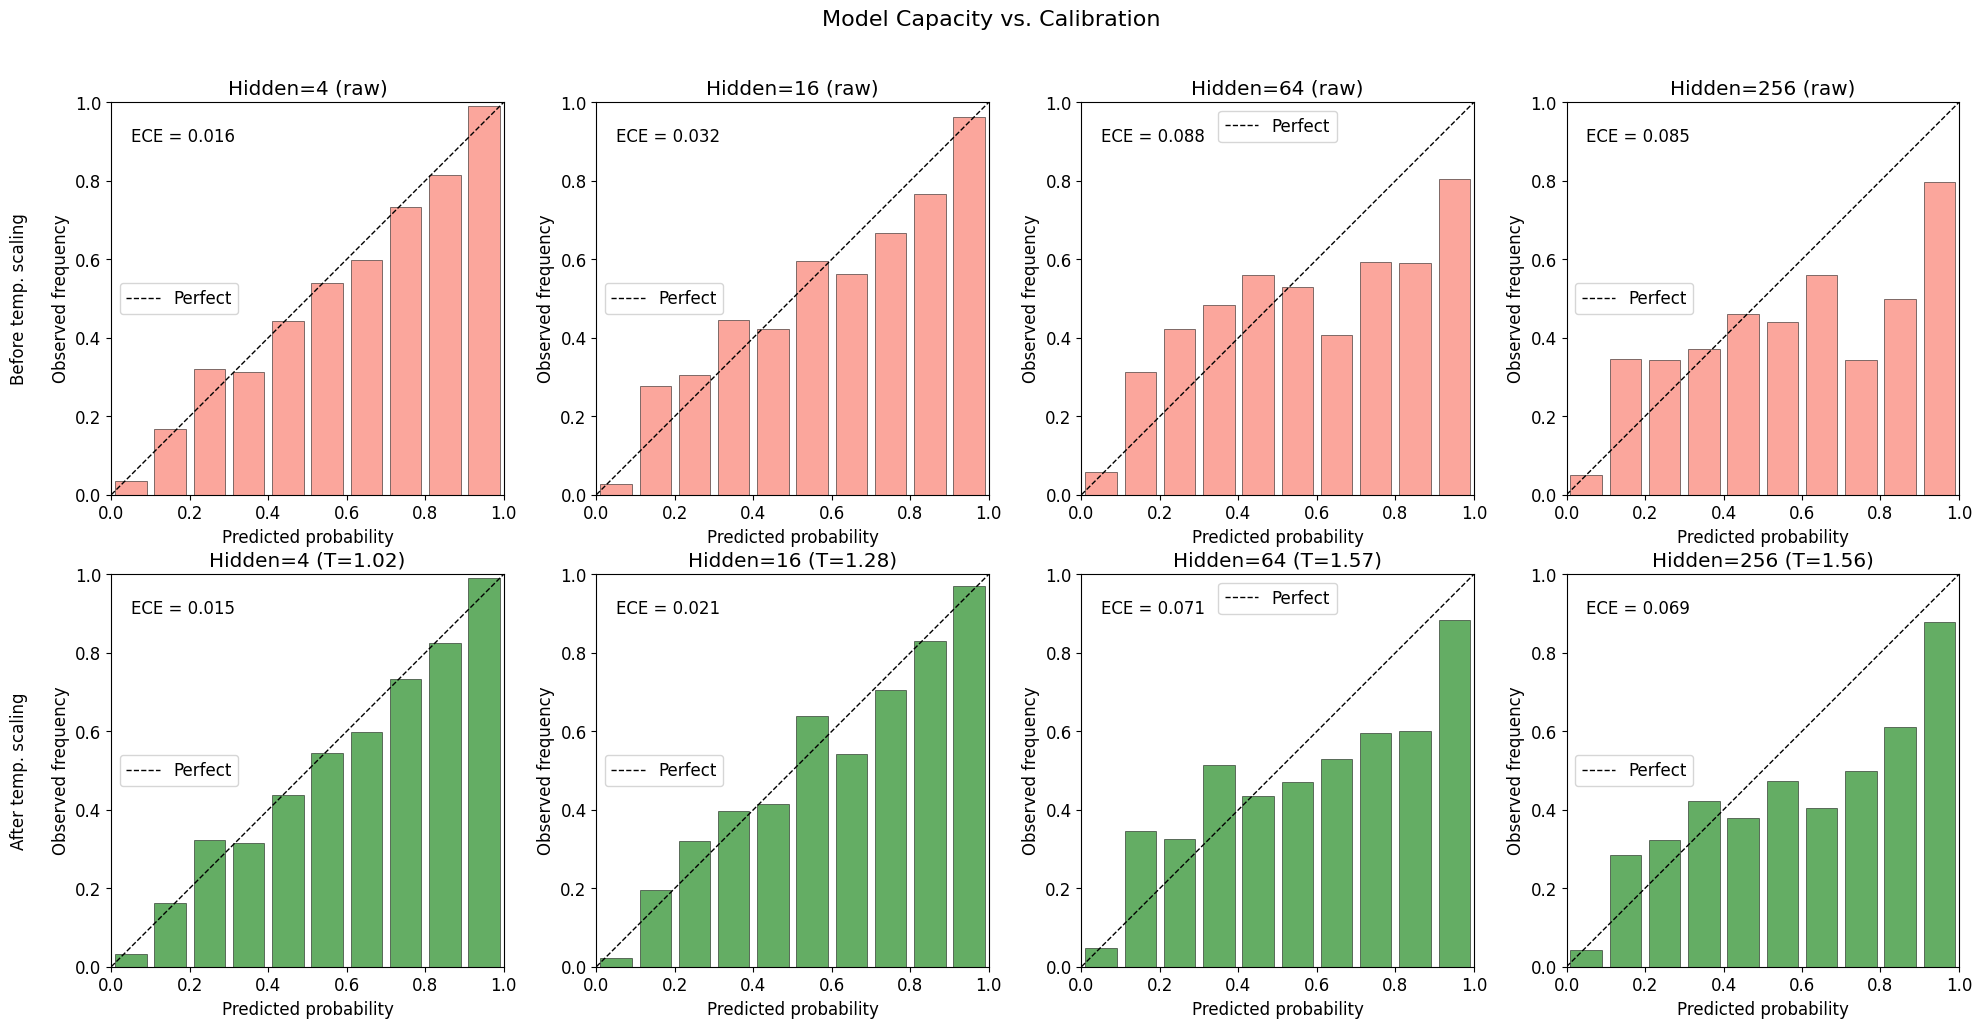

In [16]:
# --- Visualization: reliability diagrams for all model sizes ---
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for j, r in enumerate(results):
    # Top row: before temperature scaling
    reliability_diagram(r['probs_raw'], y_test.astype(float), n_bins=10, ax=axes[0, j],
                       title=f'Hidden={r["hidden"]} (raw)', color='salmon')

    # Bottom row: after temperature scaling
    reliability_diagram(r['probs_cal'], y_test.astype(float), n_bins=10, ax=axes[1, j],
                       title=f'Hidden={r["hidden"]} (T={r["T"]:.2f})', color='forestgreen')

axes[0, 0].set_ylabel('Before temp. scaling\n\nObserved frequency', fontsize=12)
axes[1, 0].set_ylabel('After temp. scaling\n\nObserved frequency', fontsize=12)

plt.suptitle('Model Capacity vs. Calibration', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

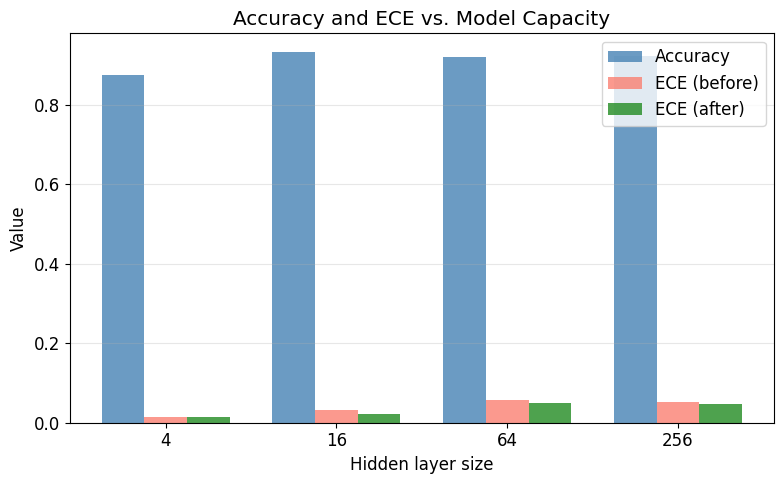

Answers:
1. Accuracy generally increases with capacity (more expressive boundary).
   ECE tends to increase too — larger models are more overconfident.
2. Usually the largest model (256) has the worst raw calibration.
3. Temperature scaling helps all models, but the improvement is larger
   for the most overconfident (largest) models.
4. T increases with capacity: larger models need more "softening".
   T values: ['1.02', '1.28', '1.57', '1.56']


In [17]:
# --- Summary plot: accuracy and ECE vs. model capacity ---
fig, ax1 = plt.subplots(figsize=(8, 5))

sizes = [r['hidden'] for r in results]
accs = [r['acc'] for r in results]
eces_before = [r['ece_before'] for r in results]
eces_after = [r['ece_after'] for r in results]
Ts = [r['T'] for r in results]

x_pos = np.arange(len(sizes))
width = 0.25

ax1.bar(x_pos - width, accs, width, label='Accuracy', color='steelblue', alpha=0.8)
ax1.bar(x_pos, eces_before, width, label='ECE (before)', color='salmon', alpha=0.8)
ax1.bar(x_pos + width, eces_after, width, label='ECE (after)', color='forestgreen', alpha=0.8)

ax1.set_xlabel('Hidden layer size')
ax1.set_ylabel('Value')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(sizes)
ax1.legend()
ax1.set_title('Accuracy and ECE vs. Model Capacity')
ax1.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print('Answers:')
print('1. Accuracy generally increases with capacity (more expressive boundary).')
print('   ECE tends to increase too — larger models are more overconfident.')
print('2. Usually the largest model (256) has the worst raw calibration.')
print('3. Temperature scaling helps all models, but the improvement is larger')
print('   for the most overconfident (largest) models.')
print('4. T increases with capacity: larger models need more "softening".')
print(f'   T values: {["{:.2f}".format(t) for t in Ts]}')